In [2]:
import subprocess
import os
import sys
import matplotlib.pyplot as plt
import pandas
import numpy as np
import subprocess

In [3]:
SEED = 42

In [4]:
commande = ["make", "run", f'ARGS=net3_1s.inp output_epanet.txt output_algo.txt 1.0 1.0 1.0 3.0 2.0 1 {SEED} 1']
resultat = subprocess.run(commande, capture_output=True, text=True)

print(resultat.stdout)
print(resultat.stderr)

./epanet_exec net3_1s.inp output_epanet.txt output_algo.txt 1.0 1.0 1.0 3.0 2.0 1 42 1

                  ÉTAT DU RÉSEAU (Temps: 0 s)                         
Sommets : 87 | Arcs : 214
Demande Globale : 36885.47 | Satisfaisabilité : 99.86%
Pression requise : 5.00 | Exposant : 0.50
Multiplicateur global de demande : 1.0000
Vitesse max Reservoir : 180.0000 m/min | arcs : 120.0000 m/min
-------------------------------------------------------------------------------------

--- LISTE DES SOMMETS ---
ID    | Type         | Elev.    | Demande      | Press.   | Degré
1     | JONCTION     | 9.75     | 2346.9554    | 4.94     | 1    
2     | JONCTION     | 3.81     | 6196.7194    | 16.71    | 1    
3     | JONCTION     | 0.00     | 0.0000       | 54.75    | 2    
4     | JONCTION     | 0.00     | 0.0000       | 54.74    | 2    
5     | JONCTION     | 12.80    | 719.0390     | 7.60     | 2    
6     | JONCTION     | 13.11    | 504.2169     | 7.29     | 2    
7     | JONCTION     | 8.69     | 512.

In [5]:
def parser(path):
    with open(path, 'r') as f:
        n = int(f.readline().strip())
        arcs_non_nulles = int(f.readline().strip())
        efficacite = float(f.readline().strip())
        sym_arcs = int(f.readline().strip())
        arcs = int(f.readline().strip())
        return (np.loadtxt(f).reshape(n, n), arcs, n, efficacite, sym_arcs, arcs_non_nulles)

parser('output_epanet.txt')

(array([[    0.    ,     0.    ,     0.    , ...,     0.    ,     0.    ,
             0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,     0.    ,
             0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,     0.    ,
             0.    ],
        ...,
        [    0.    ,     0.    ,     0.    , ...,     0.    ,   437.6261,
             0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,     0.    ,
             0.    ],
        [    0.    ,     0.    , 40751.4816, ...,     0.    ,     0.    ,
             0.    ]], shape=(87, 87)),
 214,
 87,
 0.9986,
 0,
 107)

In [6]:
def hamming_distance_non_symmetrique(m1, m2):
    return np.sum((m1 != 0) != (m2 != 0))


def hamming_distance_symmetrique(m1, m2):
    mask = np.triu(np.ones(m1.shape, dtype=bool), k=1)
    return np.sum(((m1 != 0) != (m2 != 0))[mask])


def jaccard_distance_non_symmetrique(m1, m2):
    inter = np.sum((m1 != 0.0) & (m2 != 0.0))
    union = np.sum((m1 != 0.0) | (m2 != 0.0))
    sim = inter / union if union > 0.0 else 0.0
    return 1.0 - sim


def jaccard_distance_symmetrique(m1, m2):
    mask = np.triu(np.ones(m1.shape, dtype=bool), k=1)
    inter = np.sum(((m1 != 0.0) & (m2 != 0.0))[mask])
    union = np.sum(((m1 != 0.0) | (m2 != 0.0))[mask])
    sim = inter / union if union > 0.0 else 0.0
    return 1.0 - sim


result, arcs, n, efficacite, sym_arcs, arcs_non_nulles = parser('output_epanet.txt')
print("EPANET comparaison:\n" + "nbr arcs=" + str(arcs) + "\n" + "nbr noeuds=" + str(n) + "\n" + "efficacite=" + str(efficacite) + "\n" + "sym_arcs=" + str(sym_arcs))
result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo, arcs_non_nulles_algo = parser('output_algo.txt')
print("ALGO comparaison:\n" + "nbr arcs=" + str(arcs_algo) + "\n" + "nbr noeuds=" + str(n_algo) + "\n" + "efficacite=" + str(efficacite_algo) + "\n" + "sym_arcs=" + str(sym_arcs_algo))

print(hamming_distance_non_symmetrique(result, result_algo))
print(hamming_distance_symmetrique(result, result_algo))
print(jaccard_distance_non_symmetrique(result, result_algo))
print(jaccard_distance_symmetrique(result, result_algo))

EPANET comparaison:
nbr arcs=214
nbr noeuds=87
efficacite=0.9986
sym_arcs=0
ALGO comparaison:
nbr arcs=214
nbr noeuds=87
efficacite=1.0
sym_arcs=27
60
34
0.41666666666666663
0.40476190476190477


# COMPARAISON jaccard MULTIPLCATEUR algo FF


In [7]:
multipliers_source = np.array([1.0])
multipliers_destination_epa = np.array([1.0])
multipliers_destination = np.linspace(0.001, 15.0, 1000)
VITESSE_RESERVOIR = 3.0
VITESSE_ARCS = 2.0
symm = False

In [8]:
def create_graph_hamming_mult(symm, file_input, multipliers_source, multipliers_destination, multipliers_destination_epa, vitesse_reservoir, vitesse_arcs, type_analyse):
    distances = []
    multipliers = []
    algo_satisfactions = []

    for mult_source in multipliers_source:
        for mult_destination in multipliers_destination:
            for mult_destination_epa in multipliers_destination_epa:
                commande = ["make", "run", f'ARGS={file_input} output_epanet.txt output_algo.txt {mult_source} {mult_destination} {mult_destination_epa} {vitesse_reservoir} {vitesse_arcs} {type_analyse} {SEED} 0']
                resultat = subprocess.run(commande, capture_output=True, text=True)

                result, arcs, n, efficacite, sym_arcs, arcs_non_nulles = parser('output_epanet.txt')
                result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo, arcs_non_nulles_algo = parser('output_algo.txt')

                if symm:
                    dist = jaccard_distance_symmetrique(result, result_algo)
                else:
                    dist = jaccard_distance_non_symmetrique(result, result_algo)
                distances.append(dist)
                multipliers.append(mult_destination)
                algo_satisfactions.append(efficacite_algo)

    fig, ax = plt.subplots()
    sc = ax.scatter(multipliers, distances, c=algo_satisfactions, cmap='viridis', s=20)
    ax.set_xlabel('Multiplier')
    ax.set_ylabel('jaccard Distance')
    ax.set_title('jaccard Distance vs. Multiplier')
    ax.grid(True)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Satisfaction algorithme')

    # Add number of nodes and arcs at top right
    ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes Epanet: {arcs_non_nulles}', 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top', 
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.show()

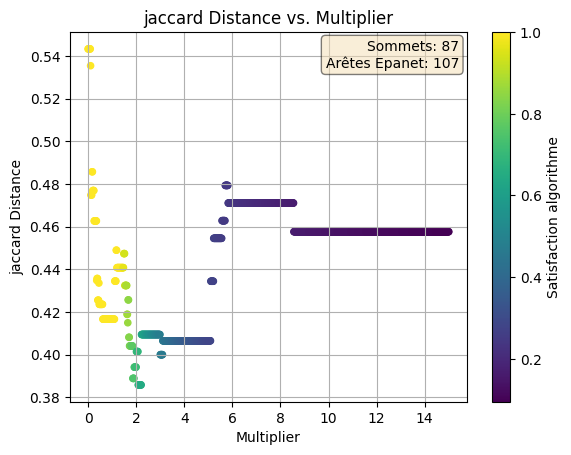

In [9]:
create_graph_hamming_mult(symm, 'net3_1s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

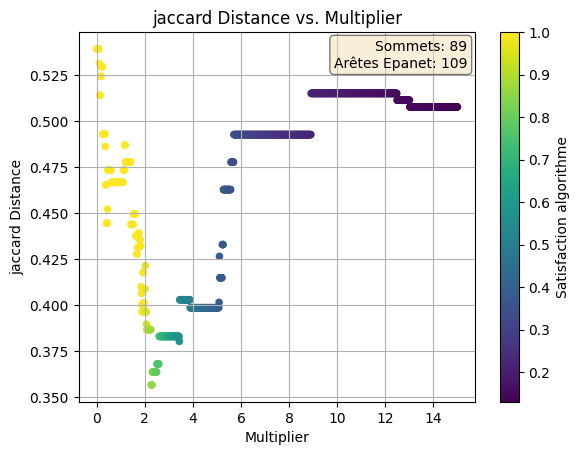

In [10]:
create_graph_hamming_mult(symm, 'net3_2s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

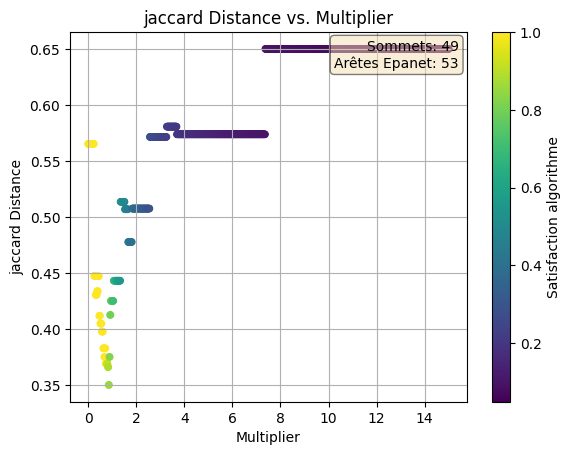

In [11]:
create_graph_hamming_mult(symm, 'generated_2s_demandes_satisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

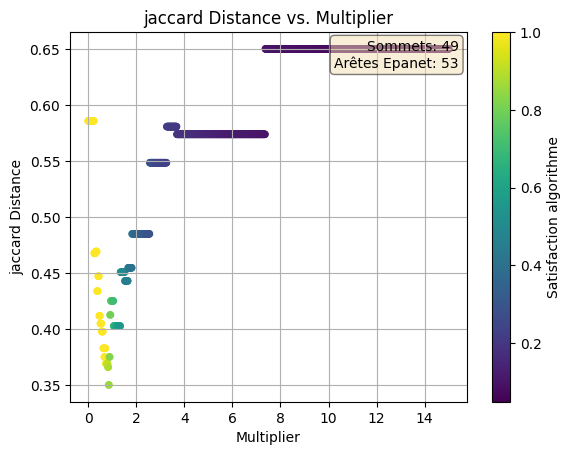

In [12]:
create_graph_hamming_mult(symm, 'generated_2s_demandes_insatisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)


# COMPARAISON satifaisabilite en fonction multiplicateur


In [13]:
multipliers_source = np.array([1.0])
multipliers_destination_epa = np.linspace(0.01, 50.0, 1000)
multipliers_destination = np.array([1.0])
VITESSE_RESERVOIR = 3.0
VITESSE_ARCS = 2.0
symm = True

In [14]:
def create_graph_jaccard_satisf(symm, file_input, multipliers_source, multipliers_destination, multipliers_destination_epa, vitesse_reservoir, vitesse_arcs, type_analyse):
    distances = []
    satisfactions = []
    mults = []

    for mult_source in multipliers_source:
        for mult_destination_epa in multipliers_destination_epa:
            commande = ["make", "run", f'ARGS={file_input} output_epanet.txt output_algo.txt {mult_source} {1/mult_destination_epa} {mult_destination_epa} {vitesse_reservoir} {vitesse_arcs} {type_analyse} {SEED} 0']
            resultat = subprocess.run(commande, capture_output=True, text=True)

            result, arcs, n, efficacite, sym_arcs, arcs_non_nulles = parser('output_epanet.txt')
            result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo, arcs_non_nulles_algo = parser('output_algo.txt')

            if symm:
                dist = jaccard_distance_symmetrique(result, result_algo)
            else:
                dist = jaccard_distance_non_symmetrique(result, result_algo)
            distances.append(dist)
            satisfactions.append(efficacite)
            mults.append(mult_destination_epa)

    if resultat.returncode != 0:
        print("Erreur d'exécution C :", resultat.stdout)
        print(resultat.stderr)

    fig, ax = plt.subplots()
    sc = ax.scatter(satisfactions, distances, c=mults, cmap='viridis', s=20)
    ax.set_xlabel('Taux de satisfaction EPANET')
    ax.set_ylabel('Distance de Jaccard')
    ax.set_title('Satisfaction EPANET en fonction de la distance de Jaccard')
    ax.grid(True)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Multiplicateur destination')

    ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes Epanet: {arcs_non_nulles}', 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top', 
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.show()

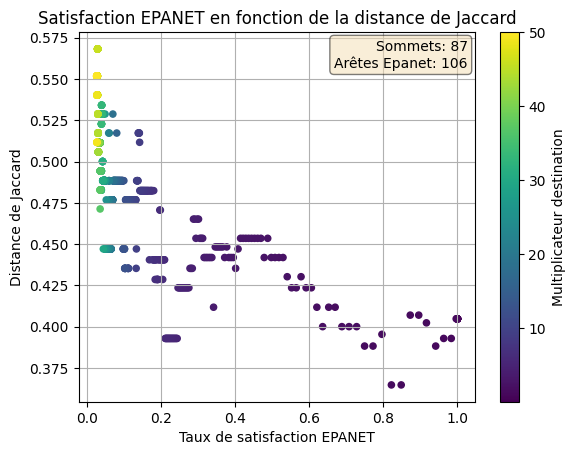

In [15]:
create_graph_jaccard_satisf(symm, 'net3_1s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

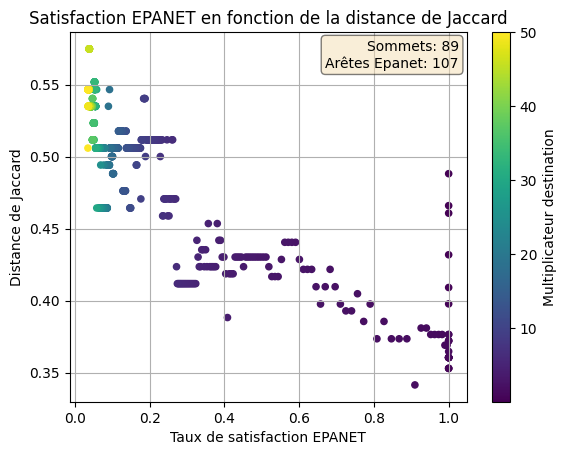

In [16]:
create_graph_jaccard_satisf(symm, 'net3_2s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

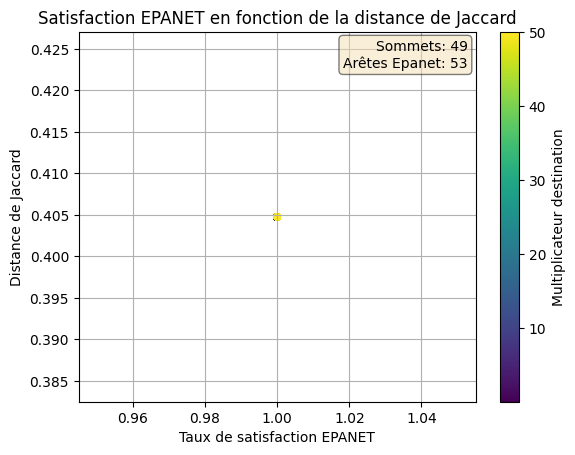

In [17]:
create_graph_jaccard_satisf(symm, 'generated_2s_demandes_satisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

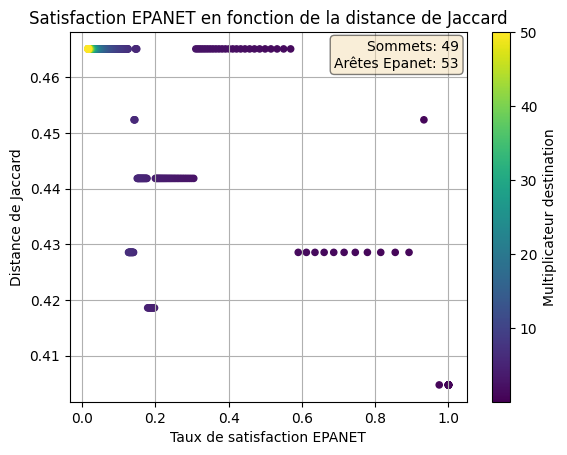

In [18]:
create_graph_jaccard_satisf(symm, 'generated_2s_demandes_insatisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

# Efficacite EPA vs Efficacite FF

In [19]:
multipliers_source = np.array([1.0])
multipliers_destination_epa = np.linspace(0.01, 10.0, 1000)
multipliers_destination = np.array([1.0])
VITESSE_RESERVOIR = 3.0
VITESSE_ARCS = 2.0
symm = True

In [20]:
def create_graph_efficacite(file_input, multipliers_source, multipliers_destination, multipliers_destination_epa, vitesse_reservoir, vitesse_arcs, type_analyse):
    epanet_effs = []
    algo_effs = []
    jaccard_distances = []

    for mult_source in multipliers_source:
        for mult_destination in multipliers_destination:
            for mult_destination_epa in multipliers_destination_epa:
                commande = ["make", "run", f'ARGS={file_input} output_epanet.txt output_algo.txt {mult_source} {mult_destination} {mult_destination_epa} {vitesse_reservoir} {vitesse_arcs} {type_analyse} {SEED} 0']
                resultat = subprocess.run(commande, capture_output=True, text=True)

                result, arcs, n, efficacite, sym_arcs, arcs_non_nulles = parser('output_epanet.txt')
                result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo, arcs_non_nulles_algo = parser('output_algo.txt')

                epanet_effs.append(efficacite)
                algo_effs.append(efficacite_algo)
                dist = jaccard_distance_symmetrique(result, result_algo)
                jaccard_distances.append(dist)

    fig, ax = plt.subplots()
    sc = ax.scatter(epanet_effs, algo_effs, c=jaccard_distances, cmap='viridis', s=20)
    ax.set_xlabel('Efficacité EPANET')
    ax.set_ylabel("Efficacité algorithme")
    ax.set_title("Efficacité EPANET vs Efficacité algorithme")
    ax.grid(True)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Distance de Jaccard')

    ax.text(0.98, 0.02,
            f'Sommets: {n}\nArêtes Epanet: {arcs_non_nulles}',
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='bottom',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.show()

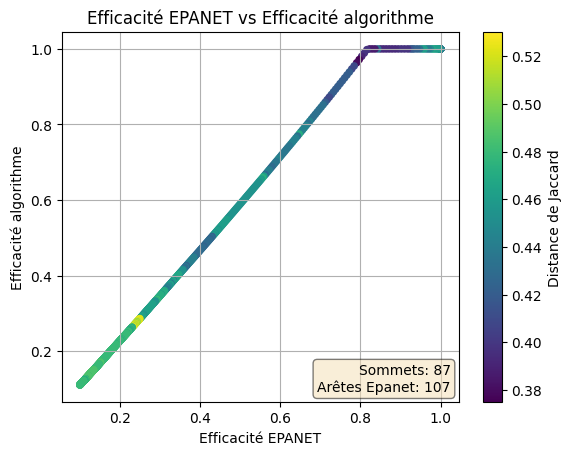

In [24]:
create_graph_efficacite('net3_1s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 2)

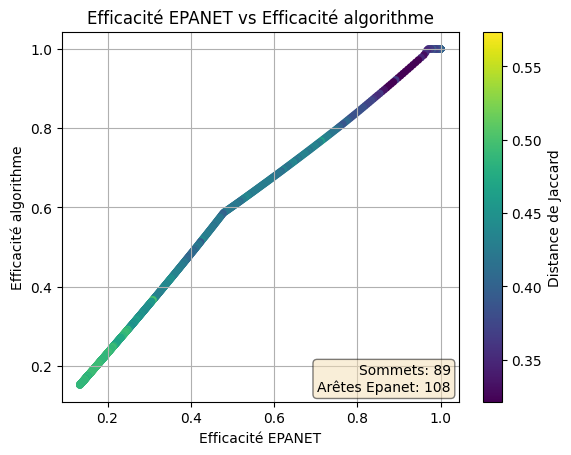

In [25]:
create_graph_efficacite('net3_2s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 2)

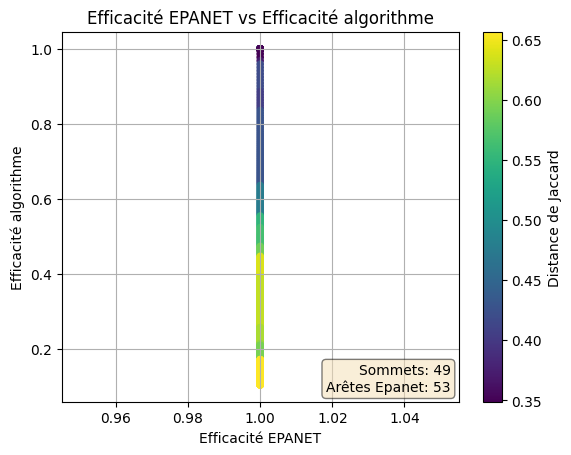

In [26]:
create_graph_efficacite('generated_2s_demandes_satisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 2)

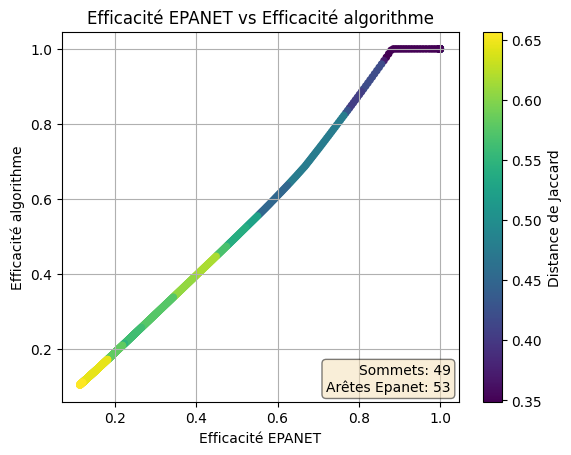

In [27]:
create_graph_efficacite('generated_2s_demandes_insatisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 2)

# COMPARE FLOW AVEC LES ORIENTATIONS CONNUES

In [ ]:
def mean_flow_difference(m1, m2, arcs_non_nulles):
    diff = np.sum(np.abs(m1 - m2)) 
    return diff / arcs_non_nulles if arcs_non_nulles > 0 else 0.0

In [ ]:
multipliers_source = np.array([1.0])
multipliers_destination_epa = np.linspace(0.01, 50.0, 1000)
multipliers_destination = np.array([1.0])
VITESSE_RESERVOIR = 3.0
VITESSE_ARCS = 2.0
symm = True

In [ ]:
def create_graph_diff_flow(symm, file_input, multipliers_source, multipliers_destination, multipliers_destination_epa, vitesse_reservoir, vitesse_arcs):
    flow_differences = []
    multipliers = []
    algo_satisfactions = []

    for mult_source in multipliers_source:
        for mult_destination in multipliers_destination:
            for mult_destination_epa in multipliers_destination_epa:
                commande = ["make", "run", f'ARGS={file_input} output_epanet.txt output_algo.txt {mult_source} {mult_destination} {mult_destination_epa} {vitesse_reservoir} {vitesse_arcs} 3 {SEED} 0']
                resultat = subprocess.run(commande, capture_output=True, text=True)

                result, arcs, n, efficacite, sym_arcs, arcs_non_nulles = parser('output_epanet.txt')
                result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo, arcs_non_nulles_algo = parser('output_algo.txt')

                # Calcul de la différence moyenne entre les flows
                diff_flow = mean_flow_difference(result, result_algo, arcs_non_nulles)
                flow_differences.append(diff_flow)
                multipliers.append(mult_destination_epa)
                algo_satisfactions.append(efficacite_algo)

    fig, ax = plt.subplots()
    sc = ax.scatter(multipliers, flow_differences, c=algo_satisfactions, cmap='viridis', s=20)
    ax.set_xlabel('Multiplier')
    ax.set_ylabel('Différence moyenne des flows')
    ax.set_title('Différence moyenne des flows vs. Multiplier')
    ax.grid(True)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Satisfaction algorithme')

    # Add number of nodes and arcs at top right
    ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes Epanet: {arcs_non_nulles}', 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top', 
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.show()

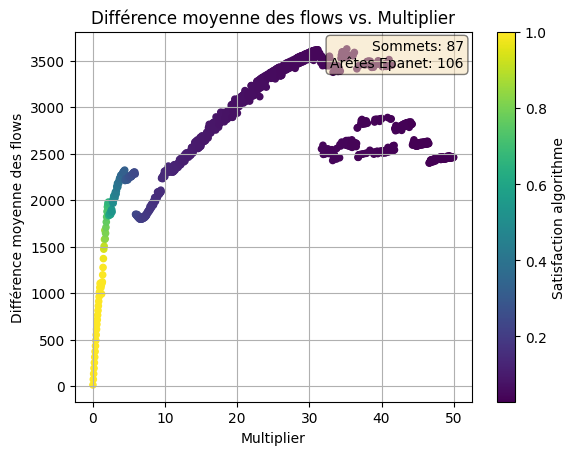

In [ ]:
create_graph_diff_flow(1, 'net3_1s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS)

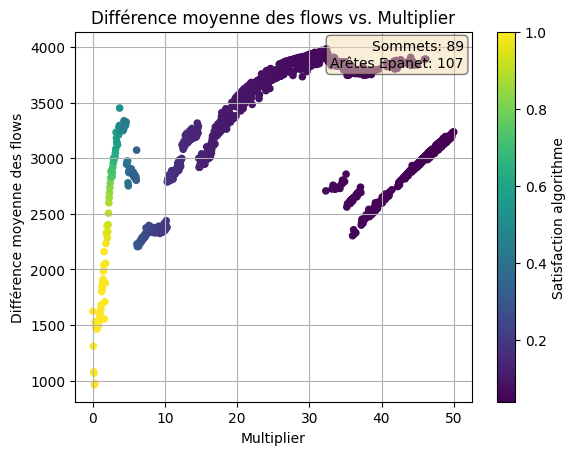

In [ ]:
create_graph_diff_flow(1, 'net3_2s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS)

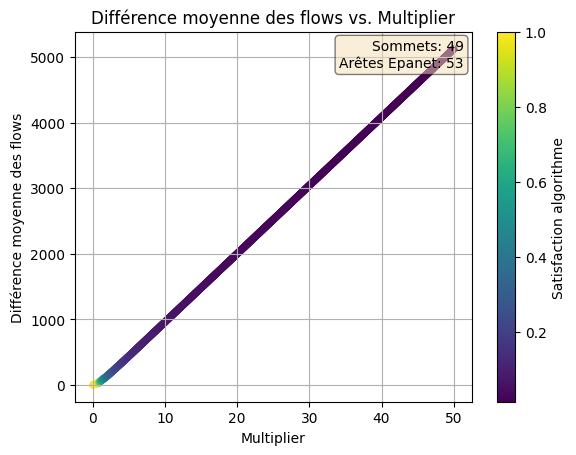

In [ ]:
create_graph_diff_flow(1, 'generated_2s_demandes_satisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS)

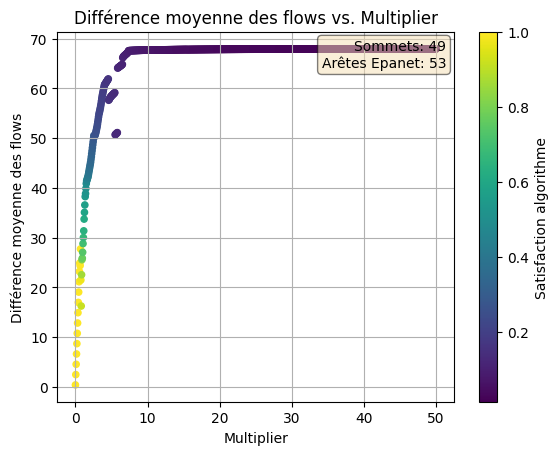

In [ ]:
create_graph_diff_flow(1, 'generated_2s_demandes_insatisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS)